In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

In [72]:
df = pd.read_csv("../data/cardekho_dataset.csv")


In [9]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [7]:
df.shape

(15411, 14)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  str    
 2   brand              15411 non-null  str    
 3   model              15411 non-null  str    
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  str    
 7   fuel_type          15411 non-null  str    
 8   transmission_type  15411 non-null  str    
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 2.3 MB


In [8]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,15411.0,9811.857699,5643.418542,0.0,4906.5,9872.00,14668.5,19543.00
vehicle_age,15411.0,6.036338,3.013291,0.0,4.0,6.00,8.0,29.00
km_driven,15411.0,55616.480631,51618.548422,100.0,30000.0,50000.00,70000.0,3800000.00
mileage,15411.0,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54
engine,15411.0,1486.057751,521.106696,793.0,1197.0,1248.00,1582.0,6592.00
max_power,15411.0,100.588254,42.972979,38.4,74.0,88.50,117.3,626.00
seats,15411.0,5.325482,0.807628,0.0,5.0,5.00,5.0,9.00
selling_price,15411.0,774971.116410,894128.363263,40000.0,385000.0,556000.00,825000.0,39500000.00


In [10]:
df.nunique()

Unnamed: 0           15411
car_name               121
brand                   32
model                  120
vehicle_age             24
km_driven             3688
seller_type              3
fuel_type                5
transmission_type        2
mileage                411
engine                 110
max_power              342
seats                    8
selling_price         1086
dtype: int64

In [11]:
df.nunique()

Unnamed: 0           15411
car_name               121
brand                   32
model                  120
vehicle_age             24
km_driven             3688
seller_type              3
fuel_type                5
transmission_type        2
mileage                411
engine                 110
max_power              342
seats                    8
selling_price         1086
dtype: int64

In [12]:
df["selling_price"].describe()

count    1.541100e+04
mean     7.749711e+05
std      8.941284e+05
min      4.000000e+04
25%      3.850000e+05
50%      5.560000e+05
75%      8.250000e+05
max      3.950000e+07
Name: selling_price, dtype: float64

In [14]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

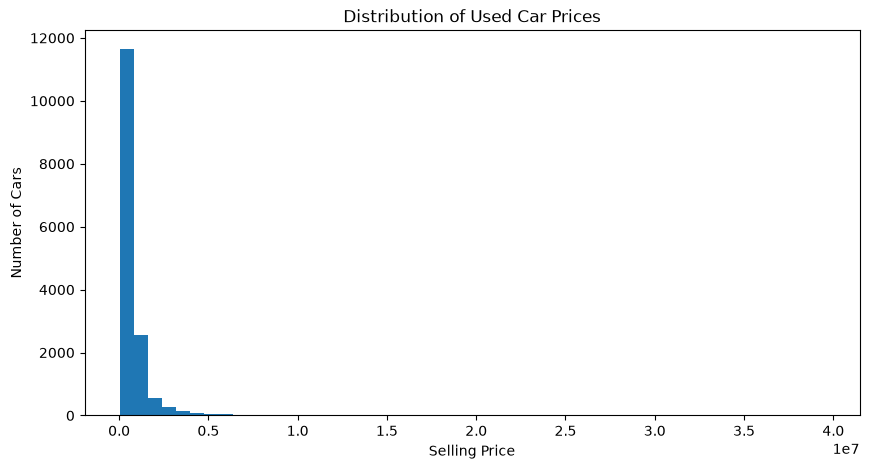

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(df["selling_price"], bins=50)

plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.title("Distribution of Used Car Prices")

plt.show()

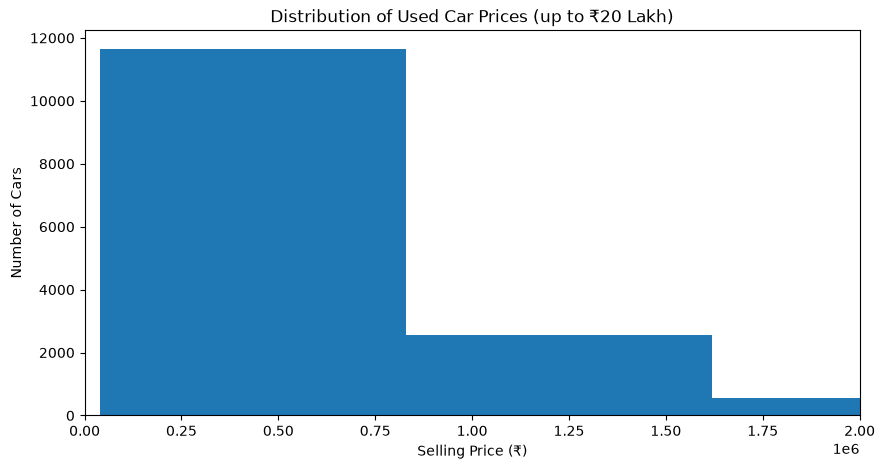

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(df["selling_price"], bins=50)

plt.xlim(0, 2000000)

plt.xlabel("Selling Price (₹)")
plt.ylabel("Number of Cars")
plt.title("Distribution of Used Car Prices (up to ₹20 Lakh)")

plt.show()

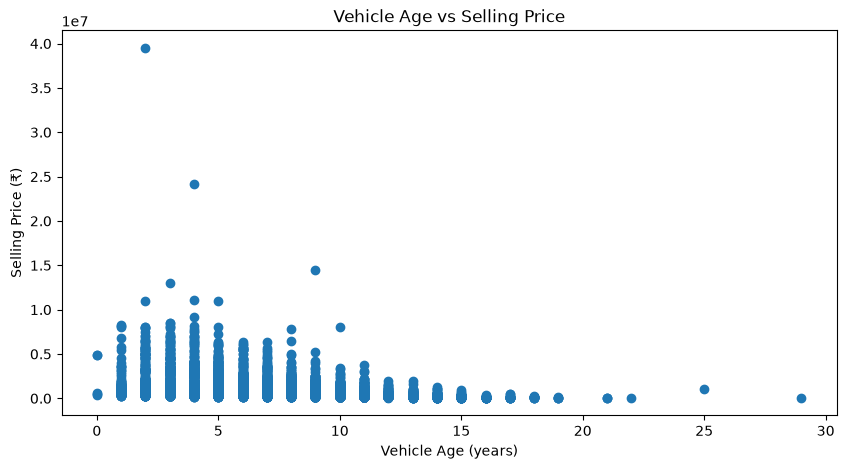

In [14]:
plt.figure(figsize=(10, 5))

plt.scatter(df["vehicle_age"], df["selling_price"])

plt.xlabel("Vehicle Age (years)")
plt.ylabel("Selling Price (₹)")
plt.title("Vehicle Age vs Selling Price")

plt.show()

In [15]:
df["vehicle_age"].corr(df["selling_price"])

np.float64(-0.24185145866968713)

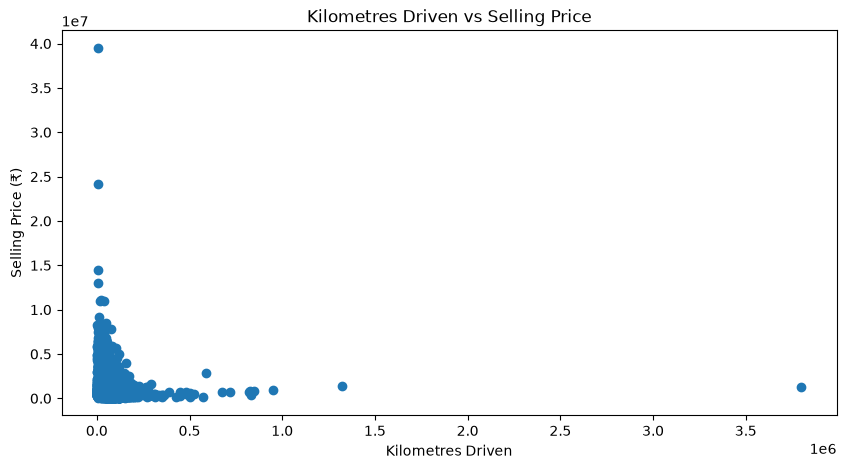

In [16]:
plt.figure(figsize=(10, 5))

plt.scatter(df["km_driven"], df["selling_price"])

plt.xlabel("Kilometres Driven")
plt.ylabel("Selling Price (₹)")
plt.title("Kilometres Driven vs Selling Price")

plt.show()

In [17]:
df["km_driven"].corr(df["selling_price"])

np.float64(-0.08003045174783589)

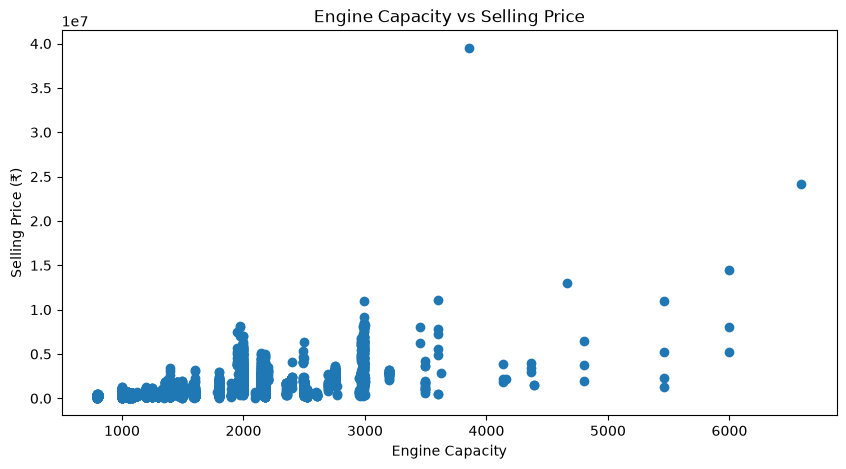

In [18]:
plt.figure(figsize=(10, 5))

plt.scatter(df["engine"], df["selling_price"])

plt.xlabel("Engine Capacity")
plt.ylabel("Selling Price (₹)")
plt.title("Engine Capacity vs Selling Price")

plt.show()

In [19]:
df["engine"].corr(df["selling_price"])

np.float64(0.5858436651172433)

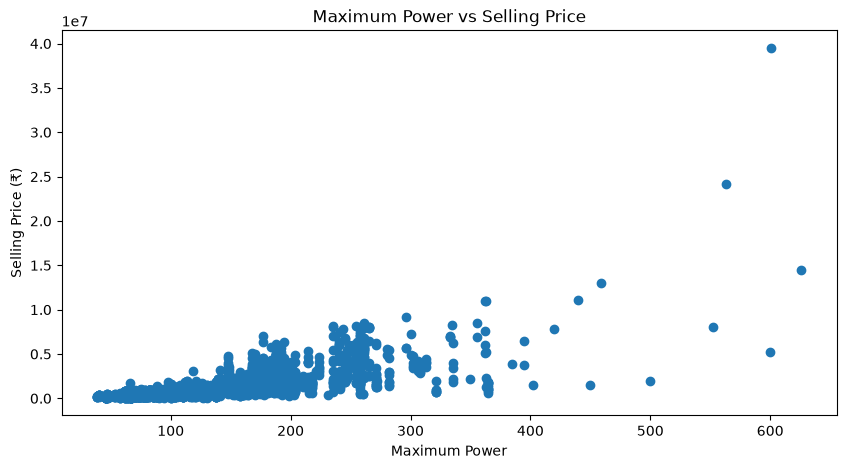

In [20]:
plt.figure(figsize=(10, 5))

plt.scatter(df["max_power"], df["selling_price"])

plt.xlabel("Maximum Power")
plt.ylabel("Selling Price (₹)")
plt.title("Maximum Power vs Selling Price")

plt.show()

In [21]:
df["max_power"].corr(df["selling_price"])

np.float64(0.7502360839249328)

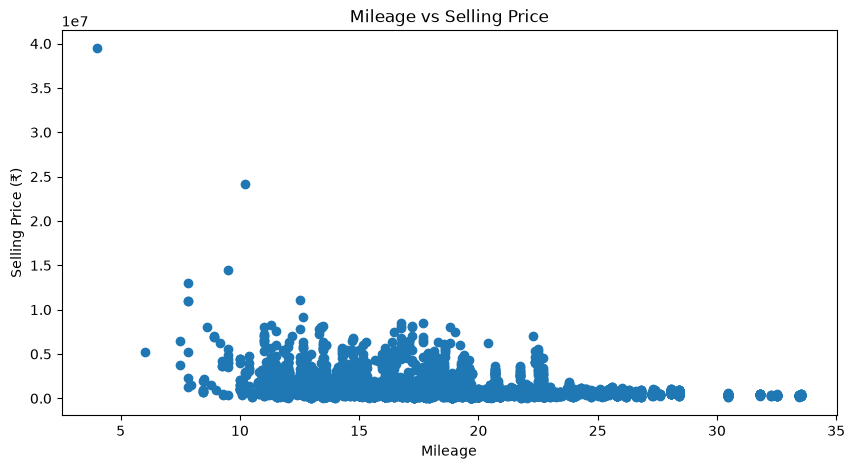

In [22]:
plt.figure(figsize=(10, 5))

plt.scatter(df["mileage"], df["selling_price"])

plt.xlabel("Mileage")
plt.ylabel("Selling Price (₹)")
plt.title("Mileage vs Selling Price")

plt.show()

In [27]:
df["mileage"].corr(df["selling_price"])

np.float64(-0.305548849972127)

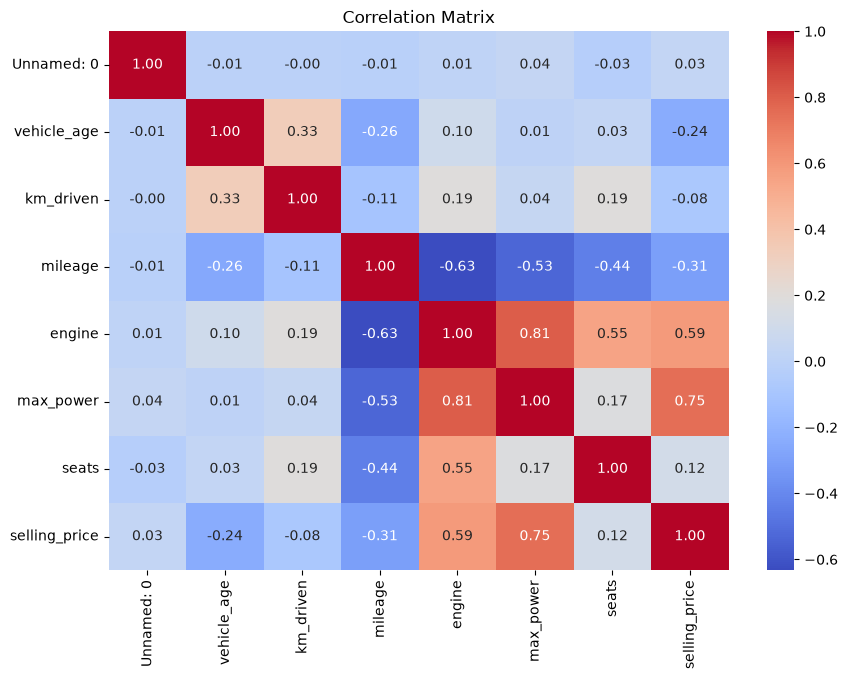

In [30]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 7))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

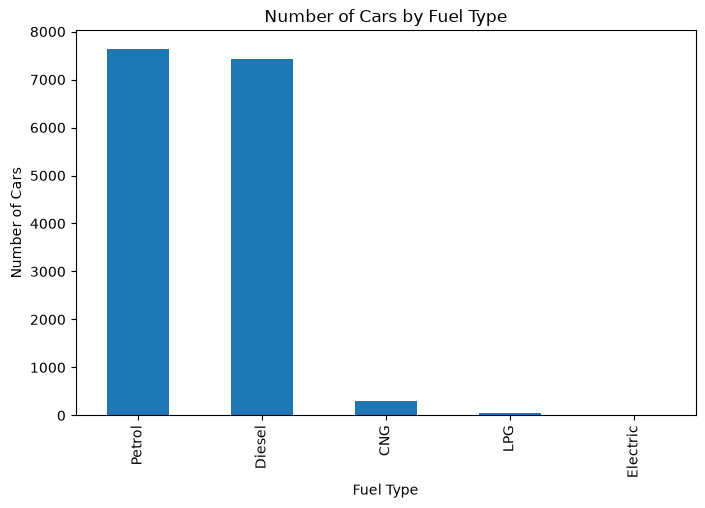

In [31]:
plt.figure(figsize=(8, 5))

df["fuel_type"].value_counts().plot(kind="bar")

plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.title("Number of Cars by Fuel Type")

plt.show()

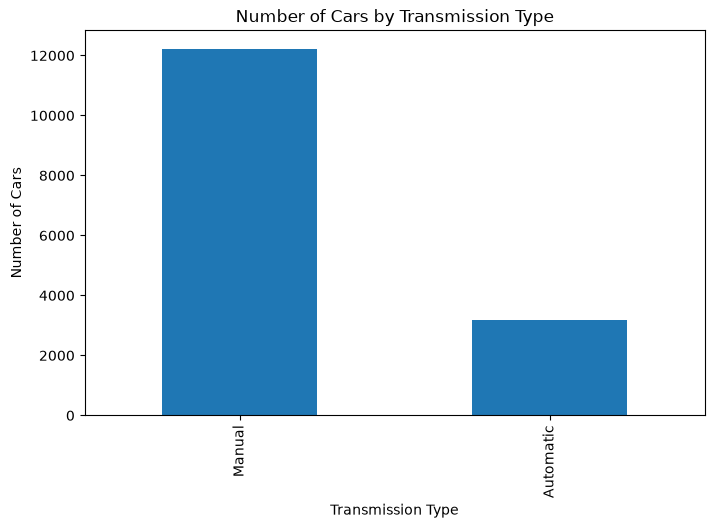

In [32]:
plt.figure(figsize=(8, 5))

df["transmission_type"].value_counts().plot(kind="bar")

plt.xlabel("Transmission Type")
plt.ylabel("Number of Cars")
plt.title("Number of Cars by Transmission Type")

plt.show()

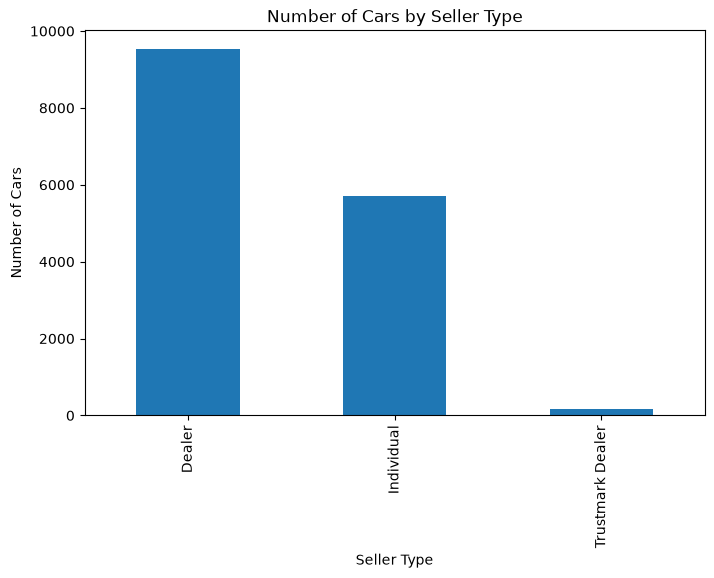

In [33]:
plt.figure(figsize=(8, 5))

df["seller_type"].value_counts().plot(kind="bar")

plt.xlabel("Seller Type")
plt.ylabel("Number of Cars")
plt.title("Number of Cars by Seller Type")

plt.show()

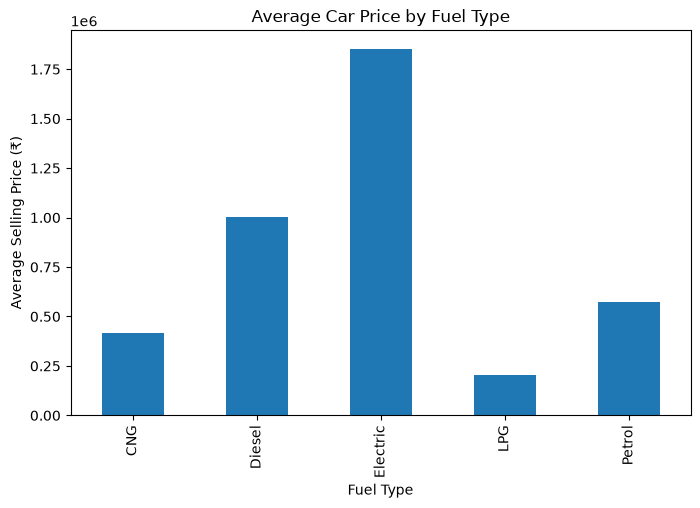

In [34]:
avg_price_fuel = df.groupby("fuel_type")["selling_price"].mean()

plt.figure(figsize=(8, 5))

avg_price_fuel.plot(kind="bar")

plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price (₹)")
plt.title("Average Car Price by Fuel Type")

plt.show()

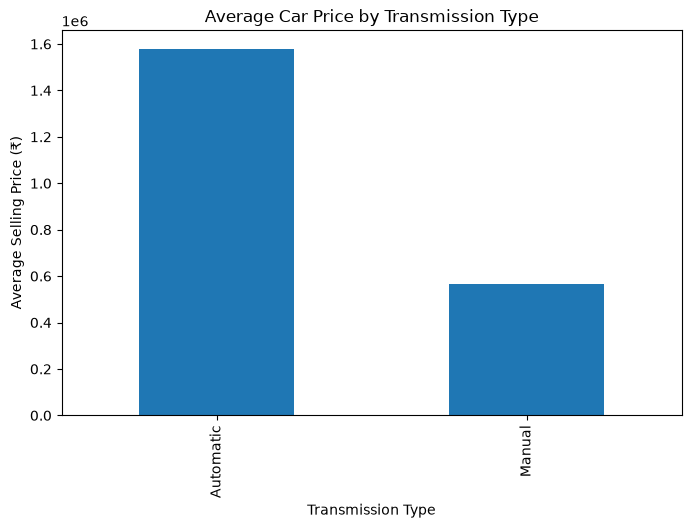

In [35]:
avg_price_transmission = df.groupby("transmission_type")["selling_price"].mean()

plt.figure(figsize=(8, 5))

avg_price_transmission.plot(kind="bar")

plt.xlabel("Transmission Type")
plt.ylabel("Average Selling Price (₹)")
plt.title("Average Car Price by Transmission Type")

plt.show()

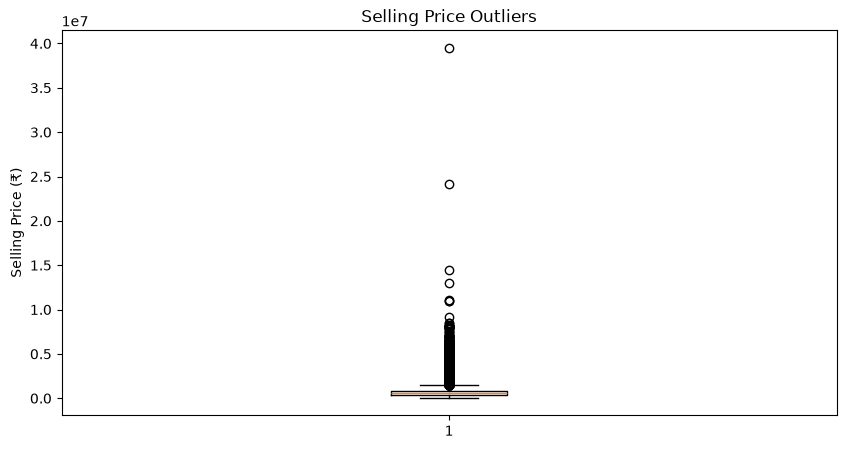

In [36]:
plt.figure(figsize=(10, 5))

plt.boxplot(df["selling_price"])

plt.ylabel("Selling Price (₹)")
plt.title("Selling Price Outliers")

plt.show()

In [37]:
df[["vehicle_age", "km_driven", "mileage", "engine", "max_power", "seats", "selling_price"]].describe().T

,count,mean,std,min,25%,50%,75%,max
vehicle_age,15411.0,6.036338,3.013291,0.0,4.0,6.00,8.0,29.00
km_driven,15411.0,55616.480631,51618.548422,100.0,30000.0,50000.00,70000.0,3800000.00
mileage,15411.0,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54
engine,15411.0,1486.057751,521.106696,793.0,1197.0,1248.00,1582.0,6592.00
max_power,15411.0,100.588254,42.972979,38.4,74.0,88.50,117.3,626.00
seats,15411.0,5.325482,0.807628,0.0,5.0,5.00,5.0,9.00
selling_price,15411.0,774971.116410,894128.363263,40000.0,385000.0,556000.00,825000.0,39500000.00


In [38]:
df[["mileage", "engine", "max_power"]].head(10)

,mileage,engine,max_power
0,19.70,796,46.30
1,18.90,1197,82.00
2,17.00,1197,80.00
3,20.92,998,67.10
4,22.77,1498,98.59
5,18.90,998,67.10
6,20.36,1197,78.90
7,20.51,998,67.04
8,18.15,998,118.35
9,16.60,1197,85.00


In [39]:
df[["vehicle_age", "km_driven", "mileage", "engine", "max_power", "seats", "selling_price"]].describe().T

,count,mean,std,min,25%,50%,75%,max
vehicle_age,15411.0,6.036338,3.013291,0.0,4.0,6.00,8.0,29.00
km_driven,15411.0,55616.480631,51618.548422,100.0,30000.0,50000.00,70000.0,3800000.00
mileage,15411.0,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54
engine,15411.0,1486.057751,521.106696,793.0,1197.0,1248.00,1582.0,6592.00
max_power,15411.0,100.588254,42.972979,38.4,74.0,88.50,117.3,626.00
seats,15411.0,5.325482,0.807628,0.0,5.0,5.00,5.0,9.00
selling_price,15411.0,774971.116410,894128.363263,40000.0,385000.0,556000.00,825000.0,39500000.00


In [40]:
df[df["km_driven"] > 1000000]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
11903,15108,Mercedes-Benz E-Class,Mercedes-Benz,E-Class,9,1325000,Dealer,Diesel,Automatic,11.5,2987,210.0,5,1350000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.0,2179,140.0,7,1225000


In [41]:
df[df["seats"] == 0]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3217,4098,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12619,15992,Nissan Kicks,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [42]:
print("Seats = 0:", (df["seats"] == 0).sum())
print("KM > 1,000,000:", (df["km_driven"] > 1000000).sum())
print("Engine > 5000:", (df["engine"] > 5000).sum())
print("Power > 500:", (df["max_power"] > 500).sum())

Seats = 0: 2
KM > 1,000,000: 2
Engine > 5000: 8
Power > 500: 5


In [11]:
df = df[df["seats"] > 0]

In [12]:
df.shape

(15409, 14)

In [13]:
df = df.drop(columns=["Unnamed: 0"])

In [14]:
df.shape

(15409, 13)

In [15]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [17]:
categorical_cols = df.select_dtypes(include="object").columns

df[categorical_cols].nunique()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10444\3447291785.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


car_name             121
brand                 32
model                120
seller_type            3
fuel_type              5
transmission_type      2
dtype: int64

In [18]:
df = df.drop(columns=["car_name"])

df.shape

(15409, 12)

In [19]:
df = pd.get_dummies(
    df,
    columns=["brand", "model", "seller_type", "fuel_type", "transmission_type"],
    drop_first=True
)

df.shape

(15409, 164)

In [20]:
df.dtypes.value_counts()

bool       157
int64        5
float64      2
Name: count, dtype: int64

In [21]:
df = df.astype(int)

df.dtypes.value_counts()

int64    164
Name: count, dtype: int64

In [23]:
x = df.drop(columns=["selling_price"])
y = df["selling_price"]

In [25]:
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (15409, 163)
y shape: (15409,)


In [27]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=50
)

In [31]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [32]:
model = LinearRegression()

model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](163,)","[-235044.52, -40581.04, -13798.38,..., 11449.49, -8388.33, -25033.91]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.789e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,163
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(132)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](163,)","[251.48,195.36,175. ,..., 0. , 0. , 0. ]"


In [34]:
y_pred = model.predict(x_test_scaled)

In [35]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.7747235261118307


In [36]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 173213.59020902266


In [37]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 138307193076.49564


In [45]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 371896.75055920513


In [46]:
ridge_model = Ridge(alpha=1.0)

In [47]:
ridge_model.fit(x_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [48]:
ridge_pred = ridge_model.predict(x_test_scaled)

In [49]:
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)

print("Ridge R²:", ridge_r2)
print("Ridge MAE:", ridge_mae)
print("Ridge MSE:", ridge_mse)
print("Ridge RMSE:", ridge_rmse)

Ridge R²: 0.7747207433447942
Ridge MAE: 173204.2674769533
Ridge MSE: 138308901540.28308
Ridge RMSE: 371899.04751193314


In [50]:
lasso_model = Lasso(alpha=1.0)

In [51]:
lasso_model.fit(x_train_scaled, y_train)

D:\Used_Car_Price_Prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.035630e+14, tolerance: 1.043e+12
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [52]:
lasso_pred = lasso_model.predict(x_test_scaled)

In [53]:
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)

print("Lasso R²:", lasso_r2)
print("Lasso MAE:", lasso_mae)
print("Lasso MSE:", lasso_mse)
print("Lasso RMSE:", lasso_rmse)

Lasso R²: 0.7851403672341013
Lasso MAE: 172217.7032607097
Lasso MSE: 131911833492.43074
Lasso RMSE: 363196.68706147466


In [57]:
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

In [58]:
lasso_grid = GridSearchCV(
    Lasso(),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(x_train_scaled, y_train)

print("Best Alpha:", lasso_grid.best_params_["alpha"])
print("Best Cross-Validation R²:", lasso_grid.best_score_)

Best Alpha: 0.01
Best Cross-Validation R²: 0.7119434817422233


D:\Used_Car_Price_Prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.841389e+14, tolerance: 1.043e+12
  model = cd_fast.enet_coordinate_descent(


In [59]:
lasso_grid.fit(x_train_scaled, y_train)

D:\Used_Car_Price_Prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.841389e+14, tolerance: 1.043e+12
  model = cd_fast.enet_coordinate_descent(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more 

In [60]:
lasso_grid.best_params_

{'alpha': 0.01}

In [61]:
lasso_grid.best_score_

np.float64(0.7119434817422233)

In [62]:
tuned_lasso = lasso_grid.best_estimator_

tuned_lasso_pred = tuned_lasso.predict(x_test_scaled)

tuned_lasso_r2 = r2_score(y_test, tuned_lasso_pred)
tuned_lasso_mae = mean_absolute_error(y_test, tuned_lasso_pred)
tuned_lasso_mse = mean_squared_error(y_test, tuned_lasso_pred)
tuned_lasso_rmse = np.sqrt(tuned_lasso_mse)

print("Tuned Lasso R²:", tuned_lasso_r2)
print("Tuned Lasso MAE:", tuned_lasso_mae)
print("Tuned Lasso MSE:", tuned_lasso_mse)
print("Tuned Lasso RMSE:", tuned_lasso_rmse)

Tuned Lasso R²: 0.7854724930509838
Tuned Lasso MAE: 172176.29455985324
Tuned Lasso MSE: 131707926760.90019
Tuned Lasso RMSE: 362915.8673313971


In [68]:
y_log = np.log1p(y)

In [69]:
x_train_log, x_test_log, y_train_log, y_test_log = train_test_split(
    x,
    y_log,
    test_size=0.2,
    random_state=42
)

scaler_log = StandardScaler()

x_train_log_scaled = scaler_log.fit_transform(x_train_log)
x_test_log_scaled = scaler_log.transform(x_test_log)

log_lasso = Lasso(alpha=0.01)

log_lasso.fit(x_train_log_scaled, y_train_log)

log_pred = log_lasso.predict(x_test_log_scaled)

pred_price = np.expm1(log_pred)

log_r2 = r2_score(y_test, pred_price)
log_mae = mean_absolute_error(y_test, pred_price)
log_mse = mean_squared_error(y_test, pred_price)
log_rmse = np.sqrt(log_mse)

print("Log Lasso R²:", log_r2)
print("Log Lasso MAE:", log_mae)
print("Log Lasso MSE:", log_mse)
print("Log Lasso RMSE:", log_rmse)

Log Lasso R²: 0.8225305046856399
Log Lasso MAE: 138104.17769843873
Log Lasso MSE: 108956374050.03111
Log Lasso RMSE: 330085.4041759967


In [78]:
log_param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

log_lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    log_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

log_lasso_grid.fit(x_train_log_scaled, y_train_log)

print("Best Log Lasso Alpha:", log_lasso_grid.best_params_["alpha"])
print("Best Cross-Validation R²:", log_lasso_grid.best_score_)

Best Log Lasso Alpha: 0.001
Best Cross-Validation R²: 0.9249096894458322


In [79]:
tuned_log_lasso = log_lasso_grid.best_estimator_

tuned_log_pred = tuned_log_lasso.predict(x_test_log_scaled)

tuned_log_price = np.expm1(tuned_log_pred)

tuned_log_r2 = r2_score(y_test, tuned_log_price)
tuned_log_mae = mean_absolute_error(y_test, tuned_log_price)
tuned_log_mse = mean_squared_error(y_test, tuned_log_price)
tuned_log_rmse = np.sqrt(tuned_log_mse)

print("Tuned Log Lasso R²:", tuned_log_r2)
print("Tuned Log Lasso MAE:", tuned_log_mae)
print("Tuned Log Lasso MSE:", tuned_log_mse)
print("Tuned Log Lasso RMSE:", tuned_log_rmse)

Tuned Log Lasso R²: 0.8907429016557152
Tuned Log Lasso MAE: 113601.51065044032
Tuned Log Lasso MSE: 67077765977.38308
Tuned Log Lasso RMSE: 258993.7566378446


In [81]:
import joblib

joblib.dump(tuned_log_lasso, "../model/lasso_model.pkl")

['../model/lasso_model.pkl']

In [82]:
joblib.dump(scaler_log, "../model/scaler.pkl")

['../model/scaler.pkl']

In [83]:
feature_columns = x.columns.tolist()

joblib.dump(feature_columns, "../model/feature_columns.pkl")

['../model/feature_columns.pkl']